In [2]:
# 1. Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# 2. Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset Loaded Successfully!\n")


Dataset Loaded Successfully!



In [4]:

# 3. Observe statistics of all features
print("Statistical Summary:\n")
print(df.describe())


Statistical Summary:

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [5]:

# 4. Shape of dataset
print("\nShape of Dataset:")
print(df.shape)



Shape of Dataset:
(891, 12)


In [6]:

# 5. Separate features (X) and target (optional)
# Here Survived is target
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("\nFeatures separated successfully!")



Features separated successfully!


In [7]:

# 6. Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())



Missing Values:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:

# 7. Fill missing values using statistical values
# Age -> mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Embarked -> mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Cabin -> drop (too many missing)
df.drop('Cabin', axis=1, inplace=True)

print("\nMissing values handled!")



Missing values handled!


/tmp/ipykernel_502/3181208361.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_502/3181208361.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

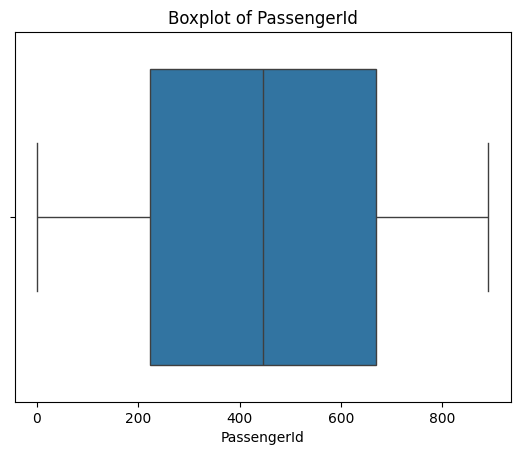

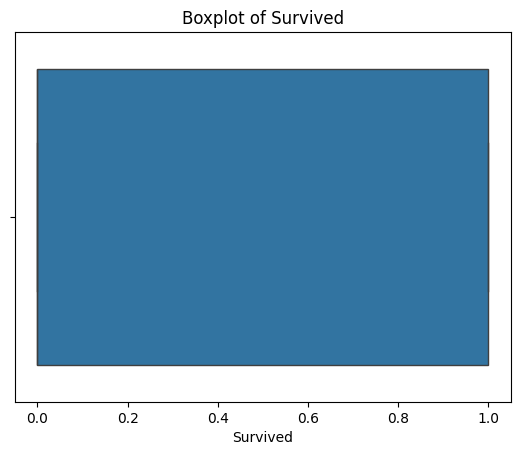

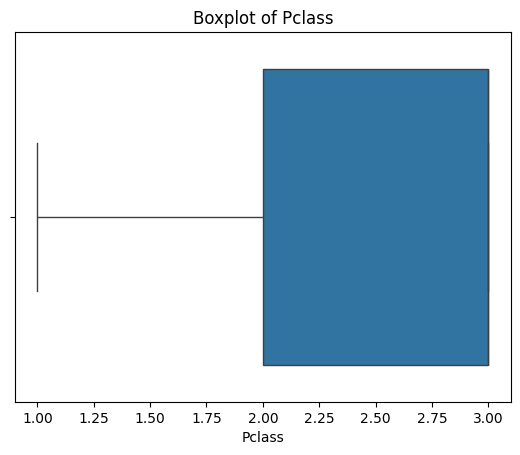

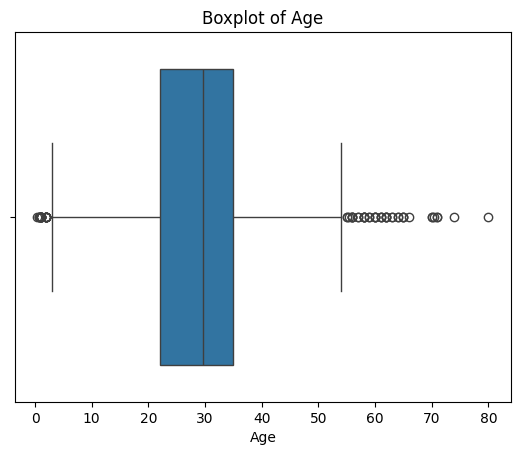

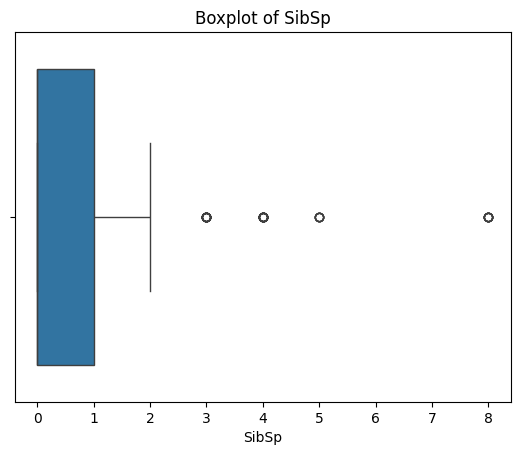

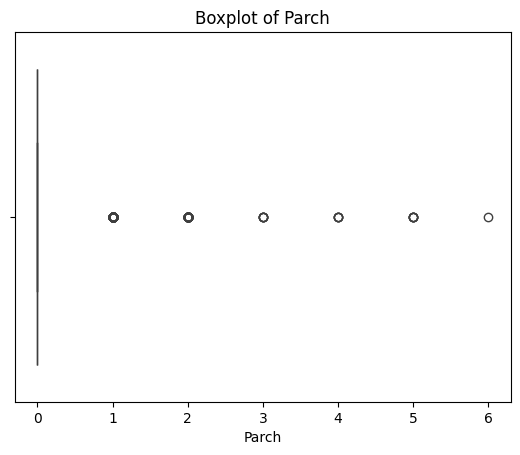

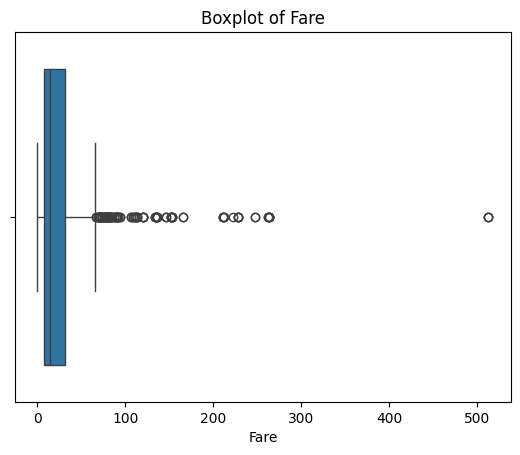

In [9]:

# 8. Boxplot of each numerical feature
numerical_features = df.select_dtypes(include=np.number).columns

for col in numerical_features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [10]:

# 9. IQR and Outlier Detection
print("\nIQR and Outliers:\n")

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}:")
    print(f"IQR = {IQR}")
    print(f"Outliers = {len(outliers)}\n")


IQR and Outliers:

PassengerId:
IQR = 445.0
Outliers = 0

Survived:
IQR = 1.0
Outliers = 0

Pclass:
IQR = 1.0
Outliers = 0

Age:
IQR = 13.0
Outliers = 66

SibSp:
IQR = 1.0
Outliers = 46

Parch:
IQR = 0.0
Outliers = 213

Fare:
IQR = 23.0896
Outliers = 116

